In [42]:
import os
import datetime

import IPython
import IPython.display
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, RepeatVector, TimeDistributed

In [43]:
path = "D:\development\predictive_pm25\data\data_training_tult.csv"

In [44]:
df = pd.read_csv(path)
df.head()

,created_at,id,temperature,humidity,sht31_temp,sht31_hum,pm25,year,month
0,2024-01-01 00:00:00,1,22.40,96.22,NaN,NaN,31.17,2024.0,1
1,2024-01-01 01:00:00,2,22.48,94.71,NaN,NaN,19.70,2024.0,1
2,2024-01-01 02:00:00,3,21.94,96.98,NaN,NaN,32.68,2024.0,1
3,2024-01-01 03:00:00,4,21.75,96.47,NaN,NaN,26.13,2024.0,1
4,2024-01-01 04:00:00,5,21.56,97.31,NaN,NaN,25.10,2024.0,1


In [45]:
if 'created_at' in df.columns:
    df['created_at'] = pd.to_datetime(df['created_at'])
    df = df.set_index('created_at')
    df.index = pd.to_datetime(df.index)
    df = df.sort_index()

print("Sample data mentah:")
print(df[['temperature', 'humidity', 'pm25']].head())
print(f"\nShape: {df.shape}")

Sample data mentah:
                     temperature  humidity   pm25
created_at                                       
2024-01-01 00:00:00        22.40     96.22  31.17
2024-01-01 01:00:00        22.48     94.71  19.70
2024-01-01 02:00:00        21.94     96.98  32.68
2024-01-01 03:00:00        21.75     96.47  26.13
2024-01-01 04:00:00        21.56     97.31  25.10

Shape: (13365, 8)


In [46]:
cols = ['temperature', 'humidity', 'pm25']
print(f"NaN sebelum: {df[cols].isna().sum().to_dict()}")
if df[cols].isna().any().any():
    full_range = pd.date_range(start=df.index.min(), end=df.index.max(), freq='h')
    df = df.reindex(full_range)
    df = df.infer_objects(copy=False)
    df = df.interpolate(method='time')
    df = df.dropna(subset=['pm25'])

    print(f"NaN setelah: {df[cols].isna().sum().to_dict()}")
else:
    print("Tidak ada NaN, skip interpolasi")
df = df.reset_index().rename(columns={'index': 'created_at'})
df = df.copy() 

NaN sebelum: {'temperature': 281, 'humidity': 113, 'pm25': 919}
NaN setelah: {'temperature': 0, 'humidity': 0, 'pm25': 0}


### Feature Engineer

#### Circular Encoding
Dalam menggunakan Circular Encoding, model LSTM terhadap konteks waktu siklus. Dengan fitur ini, Anda mengubah data "mati" menjadi fitur geografis-waktu yang sangat kuat untuk memprediksi fluktuasi polusi.

In [47]:
df['created_at'] = pd.to_datetime(df['created_at'])
timestamp_s = df['created_at'].map(pd.Timestamp.timestamp)
day = 24*60*60
year=(365.2425)*day

df['Day sin'] = np.sin(timestamp_s * (2 * np.pi / day))
df['Day cos'] = np.cos(timestamp_s * (2 * np.pi / day))
df['Year sin'] = np.sin(timestamp_s * (2 * np.pi / year))
df['Year cos'] = np.cos(timestamp_s * (2 * np.pi / year))

Text(0.5, 1.0, 'Time of day signal')

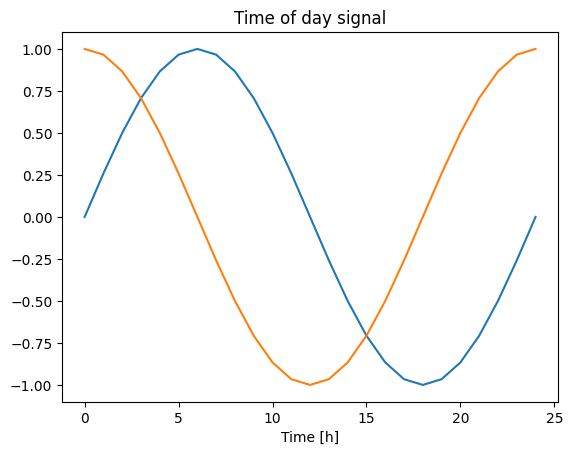

In [48]:
plt.plot(np.array(df['Day sin'])[:25])
plt.plot(np.array(df['Day cos'])[:25])
plt.xlabel('Time [h]')
plt.title('Time of day signal')

In [49]:
df_f = df.drop(columns=['created_at', 'id', 'year', 'month','sht31_temp','sht31_hum'])
df_f['pm25_diff'] = df_f['pm25'].diff().bfill()

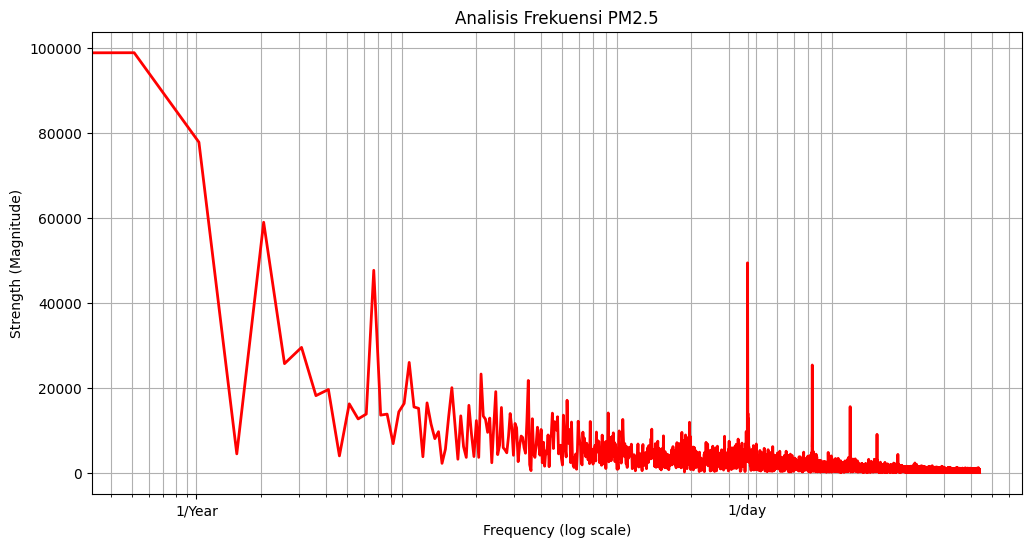

In [50]:
from scipy.fft import rfft, rfftfreq
import matplotlib.pyplot as plt
import numpy as np


data = df_f['pm25'].dropna().values

n = len(data)
yf = rfft(data - np.mean(data))
xf = rfftfreq(n, 1/24)

xf_year = xf * 365.25

plt.figure(figsize=(12, 6))
plt.semilogx(xf_year, np.abs(yf), linewidth=2, color='red')

plt.xticks([1, 365.25], labels=['1/Year', '1/day'])
plt.grid(True, which="both")
plt.xlabel('Frequency (log scale)')
plt.ylabel('Strength (Magnitude)')
plt.title('Analisis Frekuensi PM2.5')
plt.show()

### Split Data
Split the preprocessed df_f dataframe into training (70%), validation (20%), and testing (10%) sets sequentially by calculating the appropriate split indices.

In [51]:
n = len(df_f)
train_df = df_f[0:int(n*0.7)].copy()
val_df = df_f[int(n*0.7):int(n*0.9)].copy()
test_df = df_f[int(n*0.9):].copy()

print(f"Total: {n}")
print(f"Train: {len(train_df)} ({len(train_df)/n*100:.1f}%)")
print(f"Val:   {len(val_df)} ({len(val_df)/n*100:.1f}%)")
print(f"Test:  {len(test_df)} ({len(test_df)/n*100:.1f}%)")

Total: 17062
Train: 11943 (70.0%)
Val:   3412 (20.0%)
Test:  1707 (10.0%)


In [52]:
total = len(df_f)
print(f"Persentase Training: {(len(train_df)/total)*100:.2f}%")
print(f"Persentase Validation: {(len(val_df)/total)*100:.2f}%")
print(f"Persentase Testing: {(len(test_df)/total)*100:.2f}%")

Persentase Training: 70.00%
Persentase Validation: 20.00%
Persentase Testing: 10.00%


In [53]:
def analyze_outliers(df, name):
    print(f"\n{name}:")
    for col in cols:
        data = df[col]
        Q1 = data.quantile(0.25)
        Q3 = data.quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        outliers = data[(data < lower) | (data > upper)]

        print(f"  {col}:")
        print(f"     Range: [{data.min():.2f}, {data.max():.2f}]")
        print(f"     Mean: {data.mean():.2f}, Std: {data.std():.2f}")
        print(f"     Outlier IQR: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)")

analyze_outliers(train_df, "TRAIN (mentah)")
analyze_outliers(val_df, "VAL (mentah)")
analyze_outliers(test_df, "TEST (mentah)")


TRAIN (mentah):
  temperature:
     Range: [17.67, 37.56]
     Mean: 26.20, Std: 3.16
     Outlier IQR: 12 (0.10%)
  humidity:
     Range: [16.18, 100.00]
     Mean: 74.72, Std: 15.24
     Outlier IQR: 48 (0.40%)
  pm25:
     Range: [0.00, 104.80]
     Mean: 29.55, Std: 17.79
     Outlier IQR: 139 (1.16%)

VAL (mentah):
  temperature:
     Range: [21.81, 38.50]
     Mean: 28.76, Std: 3.21
     Outlier IQR: 0 (0.00%)
  humidity:
     Range: [26.57, 83.28]
     Mean: 60.49, Std: 12.13
     Outlier IQR: 0 (0.00%)
  pm25:
     Range: [0.03, 118.03]
     Mean: 50.28, Std: 20.67
     Outlier IQR: 75 (2.20%)

TEST (mentah):
  temperature:
     Range: [22.49, 36.19]
     Mean: 28.81, Std: 3.27
     Outlier IQR: 0 (0.00%)
  humidity:
     Range: [34.38, 82.27]
     Mean: 63.75, Std: 11.35
     Outlier IQR: 0 (0.00%)
  pm25:
     Range: [1.52, 104.60]
     Mean: 45.03, Std: 20.72
     Outlier IQR: 38 (2.23%)


In [54]:
# Cek apakah perlu capping
HANDLE_OUTLIER = True

if HANDLE_OUTLIER:
    # Gunakan percentile 1% dan 99% dari TRAIN
    cap_params = {}
    for col in cols:
        lower = train_df[col].quantile(0.01)
        upper = train_df[col].quantile(0.99)
        cap_params[col] = (lower, upper)

        print(f"{col}: cap ke [{lower:.2f}, {upper:.2f}]")

        # Apply ke semua split
        train_df[col] = train_df[col].clip(lower, upper)
        val_df[col] = val_df[col].clip(lower, upper)
        test_df[col] = test_df[col].clip(lower, upper)

    print("\nSetelah capping:")
    analyze_outliers(train_df, "TRAIN (capped)")

temperature: cap ke [20.36, 33.76]
humidity: cap ke [36.74, 99.08]
pm25: cap ke [0.00, 81.52]

Setelah capping:

TRAIN (capped):
  temperature:
     Range: [20.36, 33.76]
     Mean: 26.20, Std: 3.11
     Outlier IQR: 0 (0.00%)
  humidity:
     Range: [36.74, 99.08]
     Mean: 74.77, Std: 15.08
     Outlier IQR: 0 (0.00%)
  pm25:
     Range: [0.00, 81.52]
     Mean: 29.48, Std: 17.55
     Outlier IQR: 139 (1.16%)


### Normalize Data

In [55]:
from sklearn.preprocessing import StandardScaler
import joblib
scaler = StandardScaler()
scaler.fit(train_df[cols])

print("Parameter scaler (dari train):")
for i, col in enumerate(cols):
    print(f"  {col}: μ={scaler.mean_[i]:.3f}, σ={scaler.scale_[i]:.3f}")

train_scaled = train_df.copy()
val_scaled = val_df.copy()
test_scaled = test_df.copy()

train_scaled[cols] = scaler.transform(train_df[cols])
val_scaled[cols] = scaler.transform(val_df[cols])
test_scaled[cols] = scaler.transform(test_df[cols])

Parameter scaler (dari train):
  temperature: μ=26.199, σ=3.112
  humidity: μ=74.771, σ=15.081
  pm25: μ=29.477, σ=17.553


In [56]:
def verify(df, name):
    print(f"\n{name}:")
    for col in cols:
        mean = df[col].mean()
        std = df[col].std()
        min_v = df[col].min()
        max_v = df[col].max()

        # Hitung outlier |z| > 3
        z_outliers = (df[col].abs() > 3).sum()

        print(f"  {col}: μ={mean:.4f}, σ={std:.4f}, range=[{min_v:.3f}, {max_v:.3f}], |z|>3: {z_outliers}")

verify(train_scaled, "TRAIN")
verify(val_scaled, "VAL")
verify(test_scaled, "TEST")


TRAIN:
  temperature: μ=0.0000, σ=1.0000, range=[-1.875, 2.430], |z|>3: 0
  humidity: μ=0.0000, σ=1.0000, range=[-2.522, 1.612], |z|>3: 0
  pm25: μ=0.0000, σ=1.0000, range=[-1.679, 2.965], |z|>3: 0

VAL:
  temperature: μ=0.7923, σ=0.9758, range=[-1.410, 2.430], |z|>3: 0
  humidity: μ=-0.9316, σ=0.7702, range=[-2.522, 0.564], |z|>3: 0
  pm25: μ=1.1214, σ=1.0442, range=[-1.678, 2.965], |z|>3: 0

TEST:
  temperature: μ=0.8268, σ=1.0268, range=[-1.192, 2.430], |z|>3: 0
  humidity: μ=-0.7308, σ=0.7525, range=[-2.522, 0.497], |z|>3: 0
  pm25: μ=0.8556, σ=1.1137, range=[-1.593, 2.965], |z|>3: 0


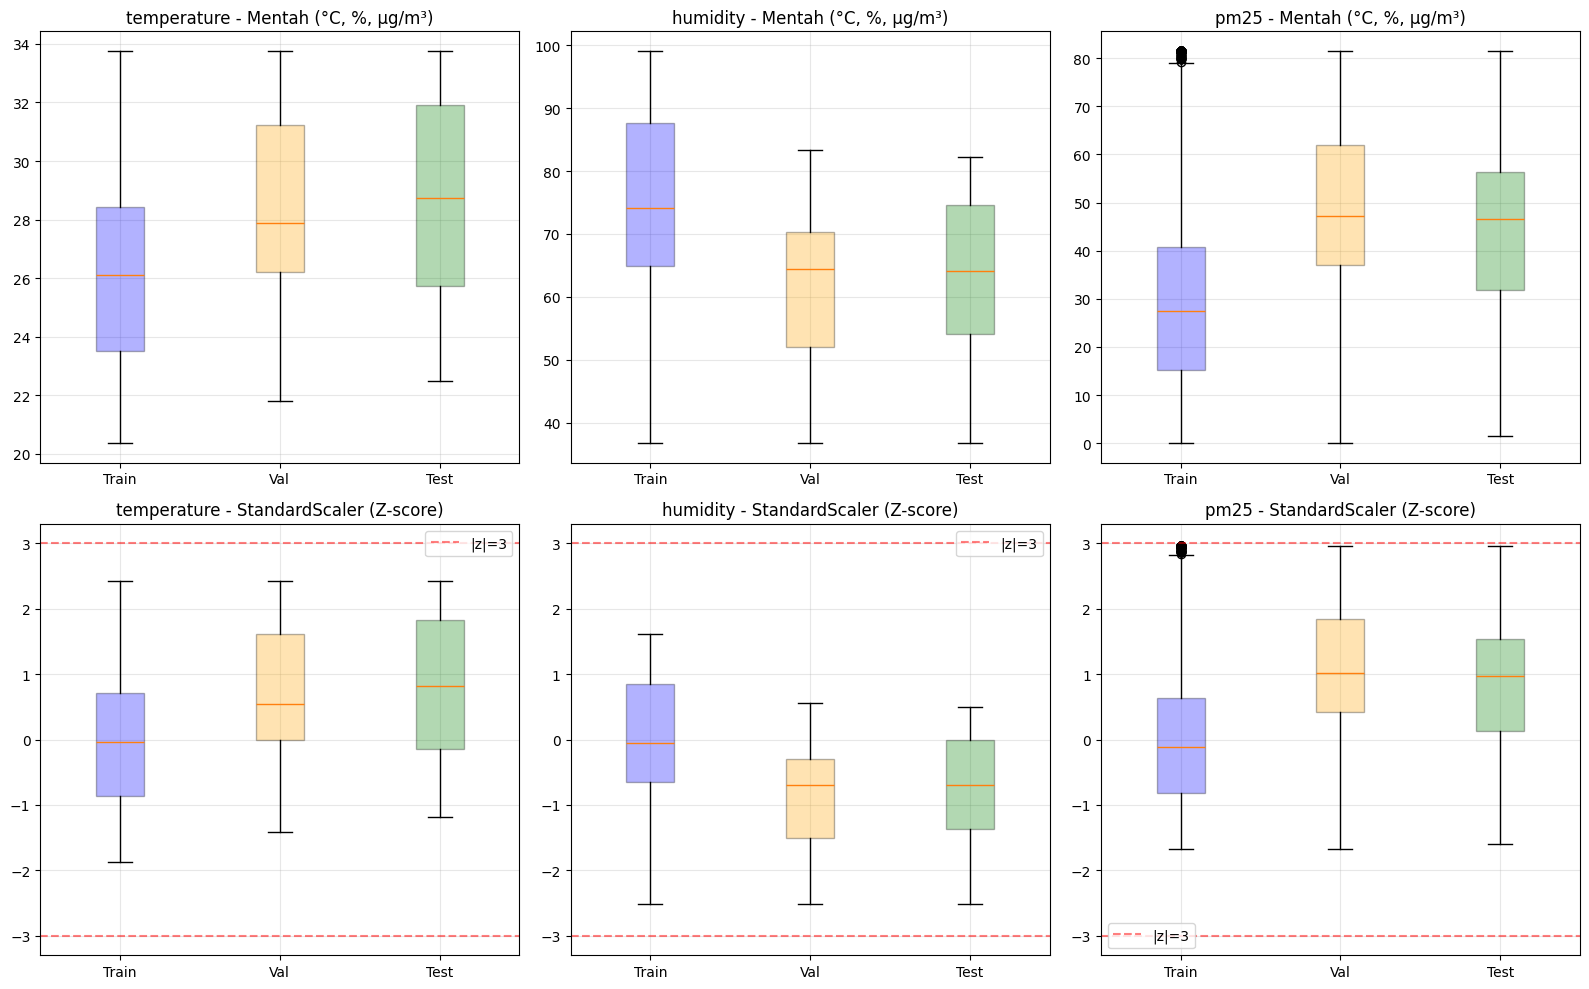

In [57]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for idx, col in enumerate(cols):
    # Before scaling
    ax1 = axes[0, idx]
    bp1 = ax1.boxplot([train_df[col], val_df[col], test_df[col]],
                      labels=['Train', 'Val', 'Test'], patch_artist=True)
    for patch, color in zip(bp1['boxes'], ['blue', 'orange', 'green']):
        patch.set_facecolor(color)
        patch.set_alpha(0.3)
    ax1.set_title(f'{col} - Mentah (°C, %, μg/m³)')
    ax1.grid(True, alpha=0.3)

    # After scaling
    ax2 = axes[1, idx]
    bp2 = ax2.boxplot([train_scaled[col], val_scaled[col], test_scaled[col]],
                      labels=['Train', 'Val', 'Test'], patch_artist=True)
    for patch, color in zip(bp2['boxes'], ['blue', 'orange', 'green']):
        patch.set_facecolor(color)
        patch.set_alpha(0.3)
    ax2.set_title(f'{col} - StandardScaler (Z-score)')
    ax2.axhline(y=3, color='r', linestyle='--', alpha=0.5, label='|z|=3')
    ax2.axhline(y=-3, color='r', linestyle='--', alpha=0.5)
    ax2.legend()
    ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [58]:
train_df = train_scaled
val_df = val_scaled
test_df = test_scaled

joblib.dump(scaler, 'scaler.pkl')
joblib.dump(cap_params, 'cap_params.pkl')

print("train_df, val_df, test_df siap digunakan!")
print("scaler.pkl dan cap_params.pkl disimpan!")

print(f"\nFinal shapes:")
print(f"  Train: {train_df.shape}")
print(f"  Val:   {val_df.shape}")
print(f"  Test:  {test_df.shape}")

train_df, val_df, test_df siap digunakan!
scaler.pkl dan cap_params.pkl disimpan!

Final shapes:
  Train: (11943, 8)
  Val:   (3412, 8)
  Test:  (1707, 8)


In [59]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, Model
import matplotlib.pyplot as plt

print("="*60)
print("PREDIKSI 1 JAM KE DEPAN - TARGET R² > 0.5")
print("="*60)

train_features = train_scaled
val_features = val_scaled
test_features = test_scaled

print(f"\nJumlah fitur: {train_features.shape[1]}")

FEATURE_COLS = ['pm25', 'temperature', 'humidity', 'pm25_diff', 'Day sin', 'Day cos', 'Year sin', 'Year cos']
LABEL_COLS = ['pm25']

class WindowGenerator():
    def __init__(self, input_width, label_width, shift,
                 train_df, val_df, test_df,
                 feature_columns, label_columns):

        self.train_df = train_df
        self.val_df = val_df
        self.test_df = test_df

        self.feature_columns = feature_columns
        self.label_columns = label_columns

        self.input_width = input_width
        self.label_width = label_width
        self.shift = shift

        self.total_window_size = input_width + shift + label_width - 1
        self.all_columns = feature_columns + label_columns

    def split_window(self, features):
        inputs = features[:, :self.input_width, :len(self.feature_columns)]
        label_start = self.input_width + self.shift - 1
        labels = features[:, label_start:label_start + self.label_width, len(self.feature_columns):]
        return inputs, labels

    def make_dataset(self, data, shuffle=True):
        data_array = data[self.all_columns].values.astype(np.float32)
        ds = tf.keras.utils.timeseries_dataset_from_array(
            data=data_array,
            targets=None,
            sequence_length=self.total_window_size,
            sequence_stride=1,
            shuffle=shuffle,
            batch_size=32,
        )
        return ds.map(self.split_window)

    @property
    def train(self):
        return self.make_dataset(self.train_df, shuffle=True)

    @property
    def val(self):
        return self.make_dataset(self.val_df, shuffle=False)

    @property
    def test(self):
        return self.make_dataset(self.test_df, shuffle=False)

multi_window = WindowGenerator(
    input_width=24,      # 24 jam history
    label_width=1,       # 1 jam prediksi
    shift=1,             # 1 jam ke depan
    train_df=train_features,
    val_df=val_features,
    test_df=test_features,
    feature_columns=FEATURE_COLS,
    label_columns=LABEL_COLS
)

def build_strong_lstm(input_width, n_features):
    """Model hibrida CNN-LSTM untuk Time-Series"""
    inputs = tf.keras.layers.Input(shape=(input_width, n_features))

    # CNN untuk mengekstrak fitur pola jam-jaman
    x = tf.keras.layers.Conv1D(filters=64, kernel_size=3, activation='relu')(inputs)
    x = tf.keras.layers.MaxPooling1D(pool_size=2)(x)
    
    # LSTM untuk membaca sequence trend panjang
    x = tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(64, return_sequences=False))(x)
    x = tf.keras.layers.Dropout(0.2)(x)
    
    x = tf.keras.layers.Dense(32, activation='relu')(x)
    
    # Output: 1 nilai (1 jam)
    outputs = tf.keras.layers.Dense(1)(x)

    return tf.keras.models.Model(inputs, outputs)

model = build_strong_lstm(24, len(FEATURE_COLS))

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.Huber(),
    metrics=['mae']
)

print("\n" + "="*60)
print("MODEL SUMMARY")
print("="*60)
model.summary()

# ============================================
# STEP 4: TRAINING DENGAN MONITORING R²
# ============================================

print("\n" + "="*60)
print("TRAINING")
print("="*60)

class R2Callback(tf.keras.callbacks.Callback):
    """Callback untuk monitoring R²"""
    def on_epoch_end(self, epoch, logs=None):
        if epoch % 10 == 0:
            # Hitung R² di validation set
            val_preds = []
            val_labels = []
            for inputs, labels in multi_window.val:
                preds = self.model.predict(inputs, verbose=0)
                val_preds.append(preds)
                val_labels.append(labels.numpy())

            val_preds = np.concatenate(val_preds)
            val_labels = np.concatenate(val_labels)

            ss_res = np.sum((val_labels - val_preds)**2)
            ss_tot = np.sum((val_labels - np.mean(val_labels))**2)
            r2 = 1 - (ss_res / ss_tot)

            print(f"Epoch {epoch}: val_loss={logs['val_loss']:.4f}, val_R²={r2:.4f}")

history = model.fit(
    multi_window.train,
    validation_data=multi_window.val,
    epochs=100,
    callbacks=[
        R2Callback(),
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=20,
            restore_best_weights=True,
            verbose=1
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=7,
            min_lr=1e-7,
            verbose=1
        )
    ]
)

# ============================================
# STEP 5: EVALUASI DETAIL
# ============================================

print("\n" + "="*60)
print("EVALUASI FINAL")
print("="*60)

def evaluate_detailed(model, window_gen, scaler):
    all_preds, all_labels = [], []

    for inputs, labels in window_gen.test:
        preds = model.predict(inputs, verbose=0)
        all_preds.append(preds)
        all_labels.append(labels.numpy())

    preds = np.concatenate(all_preds).flatten()
    labels = np.concatenate(all_labels).flatten()

    # Metrics
    mae = np.mean(np.abs(preds - labels))
    rmse = np.sqrt(np.mean((preds - labels)**2))
    mape = np.mean(np.abs((labels - preds) / (labels + 1e-8))) * 100

    ss_res = np.sum((labels - preds)**2)
    ss_tot = np.sum((labels - np.mean(labels))**2)
    r2 = 1 - (ss_res / ss_tot)

    # Convert ke skala asli
    pm25_std = scaler.scale_[2]
    pm25_mean = scaler.mean_[2]

    mae_real = mae * pm25_std
    rmse_real = rmse * pm25_std

    print(f"\n📊 METRICS (Z-Score Scale):")
    print(f"  MAE:  {mae:.4f}")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  R²:   {r2:.4f}")

    print(f"\n📊 METRICS (Skala Asli - μg/m³):")
    print(f"  MAE:  {mae_real:.2f} μg/m³")
    print(f"  RMSE: {rmse_real:.2f} μg/m³")
    print(f"  MAPE: {mape:.2f}%")

    # Korelasi
    corr = np.corrcoef(preds, labels)[0, 1]
    print(f"\n📈 Korelasi Prediksi vs Aktual: {corr:.4f}")

    # Target tercapai?
    if r2 > 0.5:
        print(f"\n✅ TARGET TERCAPAI! R² = {r2:.4f} > 0.5")
    else:
        print(f"\n⚠️  Target belum tercapai. R² = {r2:.4f}")

    return preds, labels, r2, mae_real

preds, labels, r2, mae_real = evaluate_detailed(model, multi_window, scaler)

# ============================================
# STEP 6: VISUALISASI
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot: Prediksi vs Aktual
axes[0].scatter(labels, preds, alpha=0.5, s=20)
axes[0].plot([-3, 3], [-3, 3], 'r--', label='Perfect Prediction')
axes[0].set_xlabel('Actual PM2.5 (Z-score)')
axes[0].set_ylabel('Predicted PM2.5 (Z-score)')
axes[0].set_title(f'Prediksi vs Aktual (R² = {r2:.4f})')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Time series sample
sample_size = 200
axes[1].plot(range(sample_size), labels[:sample_size], 'b-', label='Actual', linewidth=2)
axes[1].plot(range(sample_size), preds[:sample_size], 'r--', label='Predicted', linewidth=2)
axes[1].set_xlabel('Time Step')
axes[1].set_ylabel('PM2.5 (Z-score)')
axes[1].set_title('Sample Prediksi 1 Jam ke Depan')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================
# STEP 7: ERROR ANALYSIS
# ============================================

errors = labels - preds
print(f"\n" + "="*60)
print("ERROR ANALYSIS")
print("="*60)
print(f"Error mean: {np.mean(errors):.4f} (harus ~0)")
print(f"Error std:  {np.std(errors):.4f}")
print(f"Error range: [{np.min(errors):.2f}, {np.max(errors):.2f}]")

# Simpan
model.save('pm25_model_1hour.keras')
print(f"\n✅ Model disimpan ke 'pm25_model_1hour.keras'")
print(f"✅ Target R² > 0.5: {'TERCAPAI' if r2 > 0.5 else 'BELUM TERCAPAI'}")

NameError: name 'FEATURE_COLS' is not defined